In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from joblib import Parallel, delayed
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


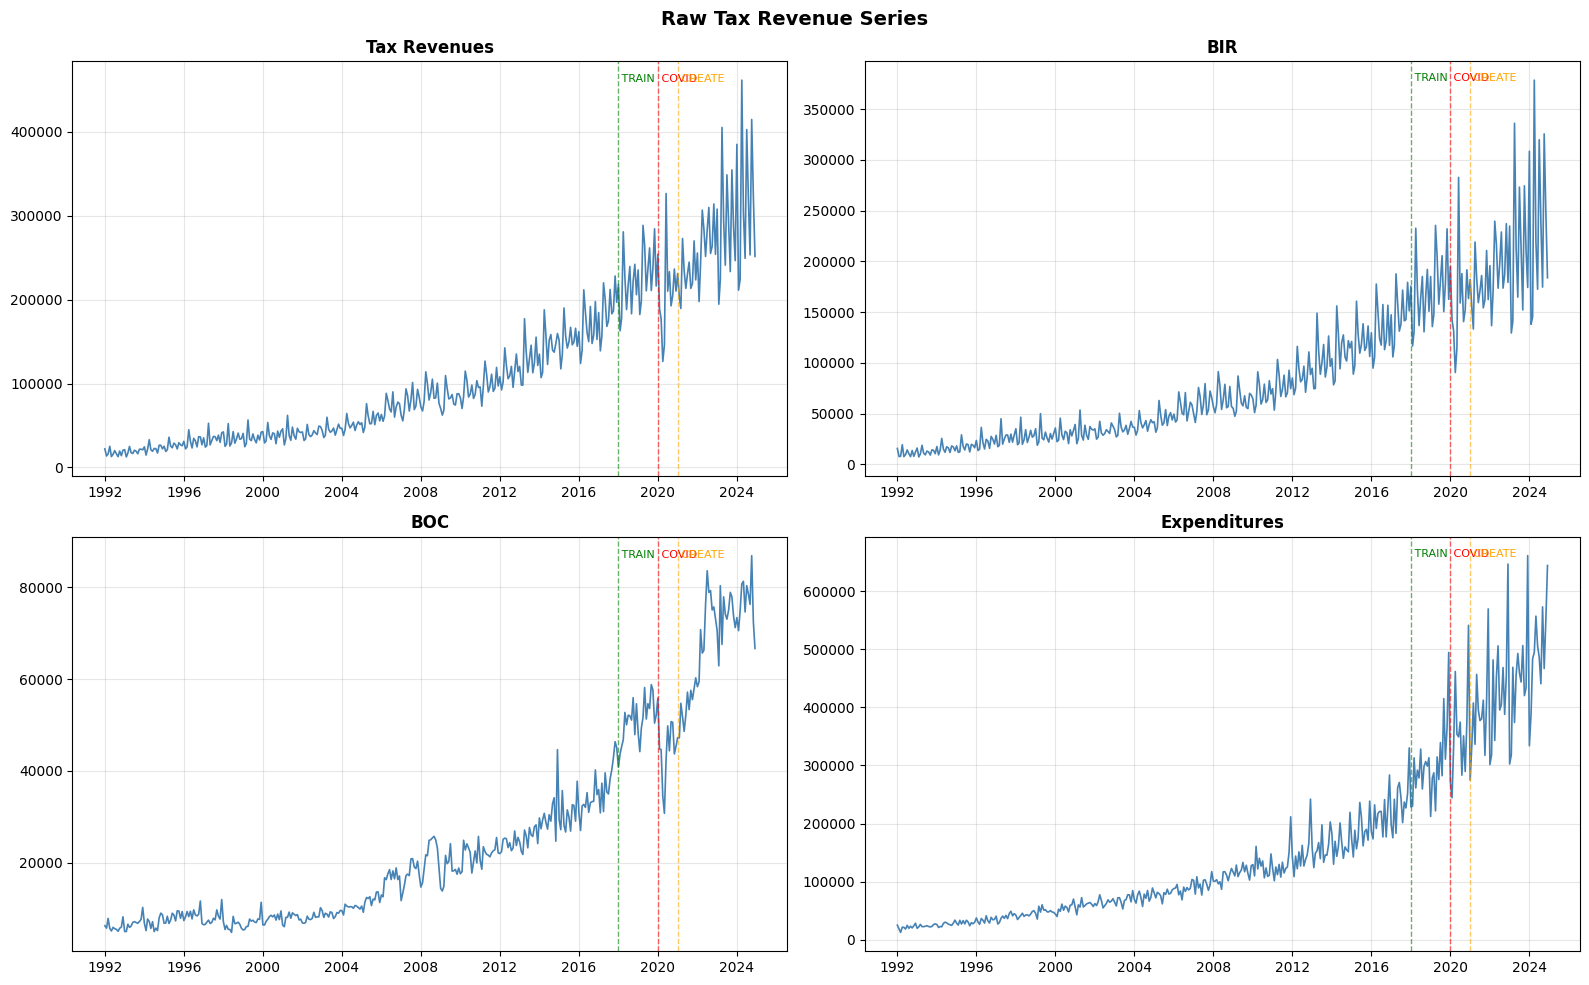

In [2]:
BREAK_LABELS = ['Tax Revenues', 'BIR', 'BOC', 'Expenditures']

# Load data — adjust filename/column as needed
df = pd.read_csv('Data/cordata.csv', parse_dates=['Date'], index_col='Date')
disagg = pd.read_csv('Data/disaggregated.csv')
disagg = disagg.rename(columns={'Unnamed: 3': 'Date'}).set_index('Date')
disagg.index = pd.to_datetime(disagg.index)

df = df.join(disagg, how='inner').sort_index()
df = df.loc['1992':]

raw_series = {}
for label in BREAK_LABELS:
    raw_series[label] = {
        'values': df[label].values,
        'dates':  df.index,
    }

# %% [markdown]
# ## Step 1: Plot Raw Series

# %%
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, label in zip(axes.flatten(), BREAK_LABELS):
    ax.plot(raw_series[label]['dates'], raw_series[label]['values'],
            linewidth=1.2, color='steelblue')
    for year, name, color in [(2018, 'TRAIN', 'green'), (2020, 'COVID', 'red'),
                               (2021, 'CREATE', 'orange')]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'), color=color,
                   linestyle='--', alpha=0.6, linewidth=1)
        ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1] * 0.95,
                f' {name}', fontsize=8, color=color)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
fig.suptitle('Raw Tax Revenue Series', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


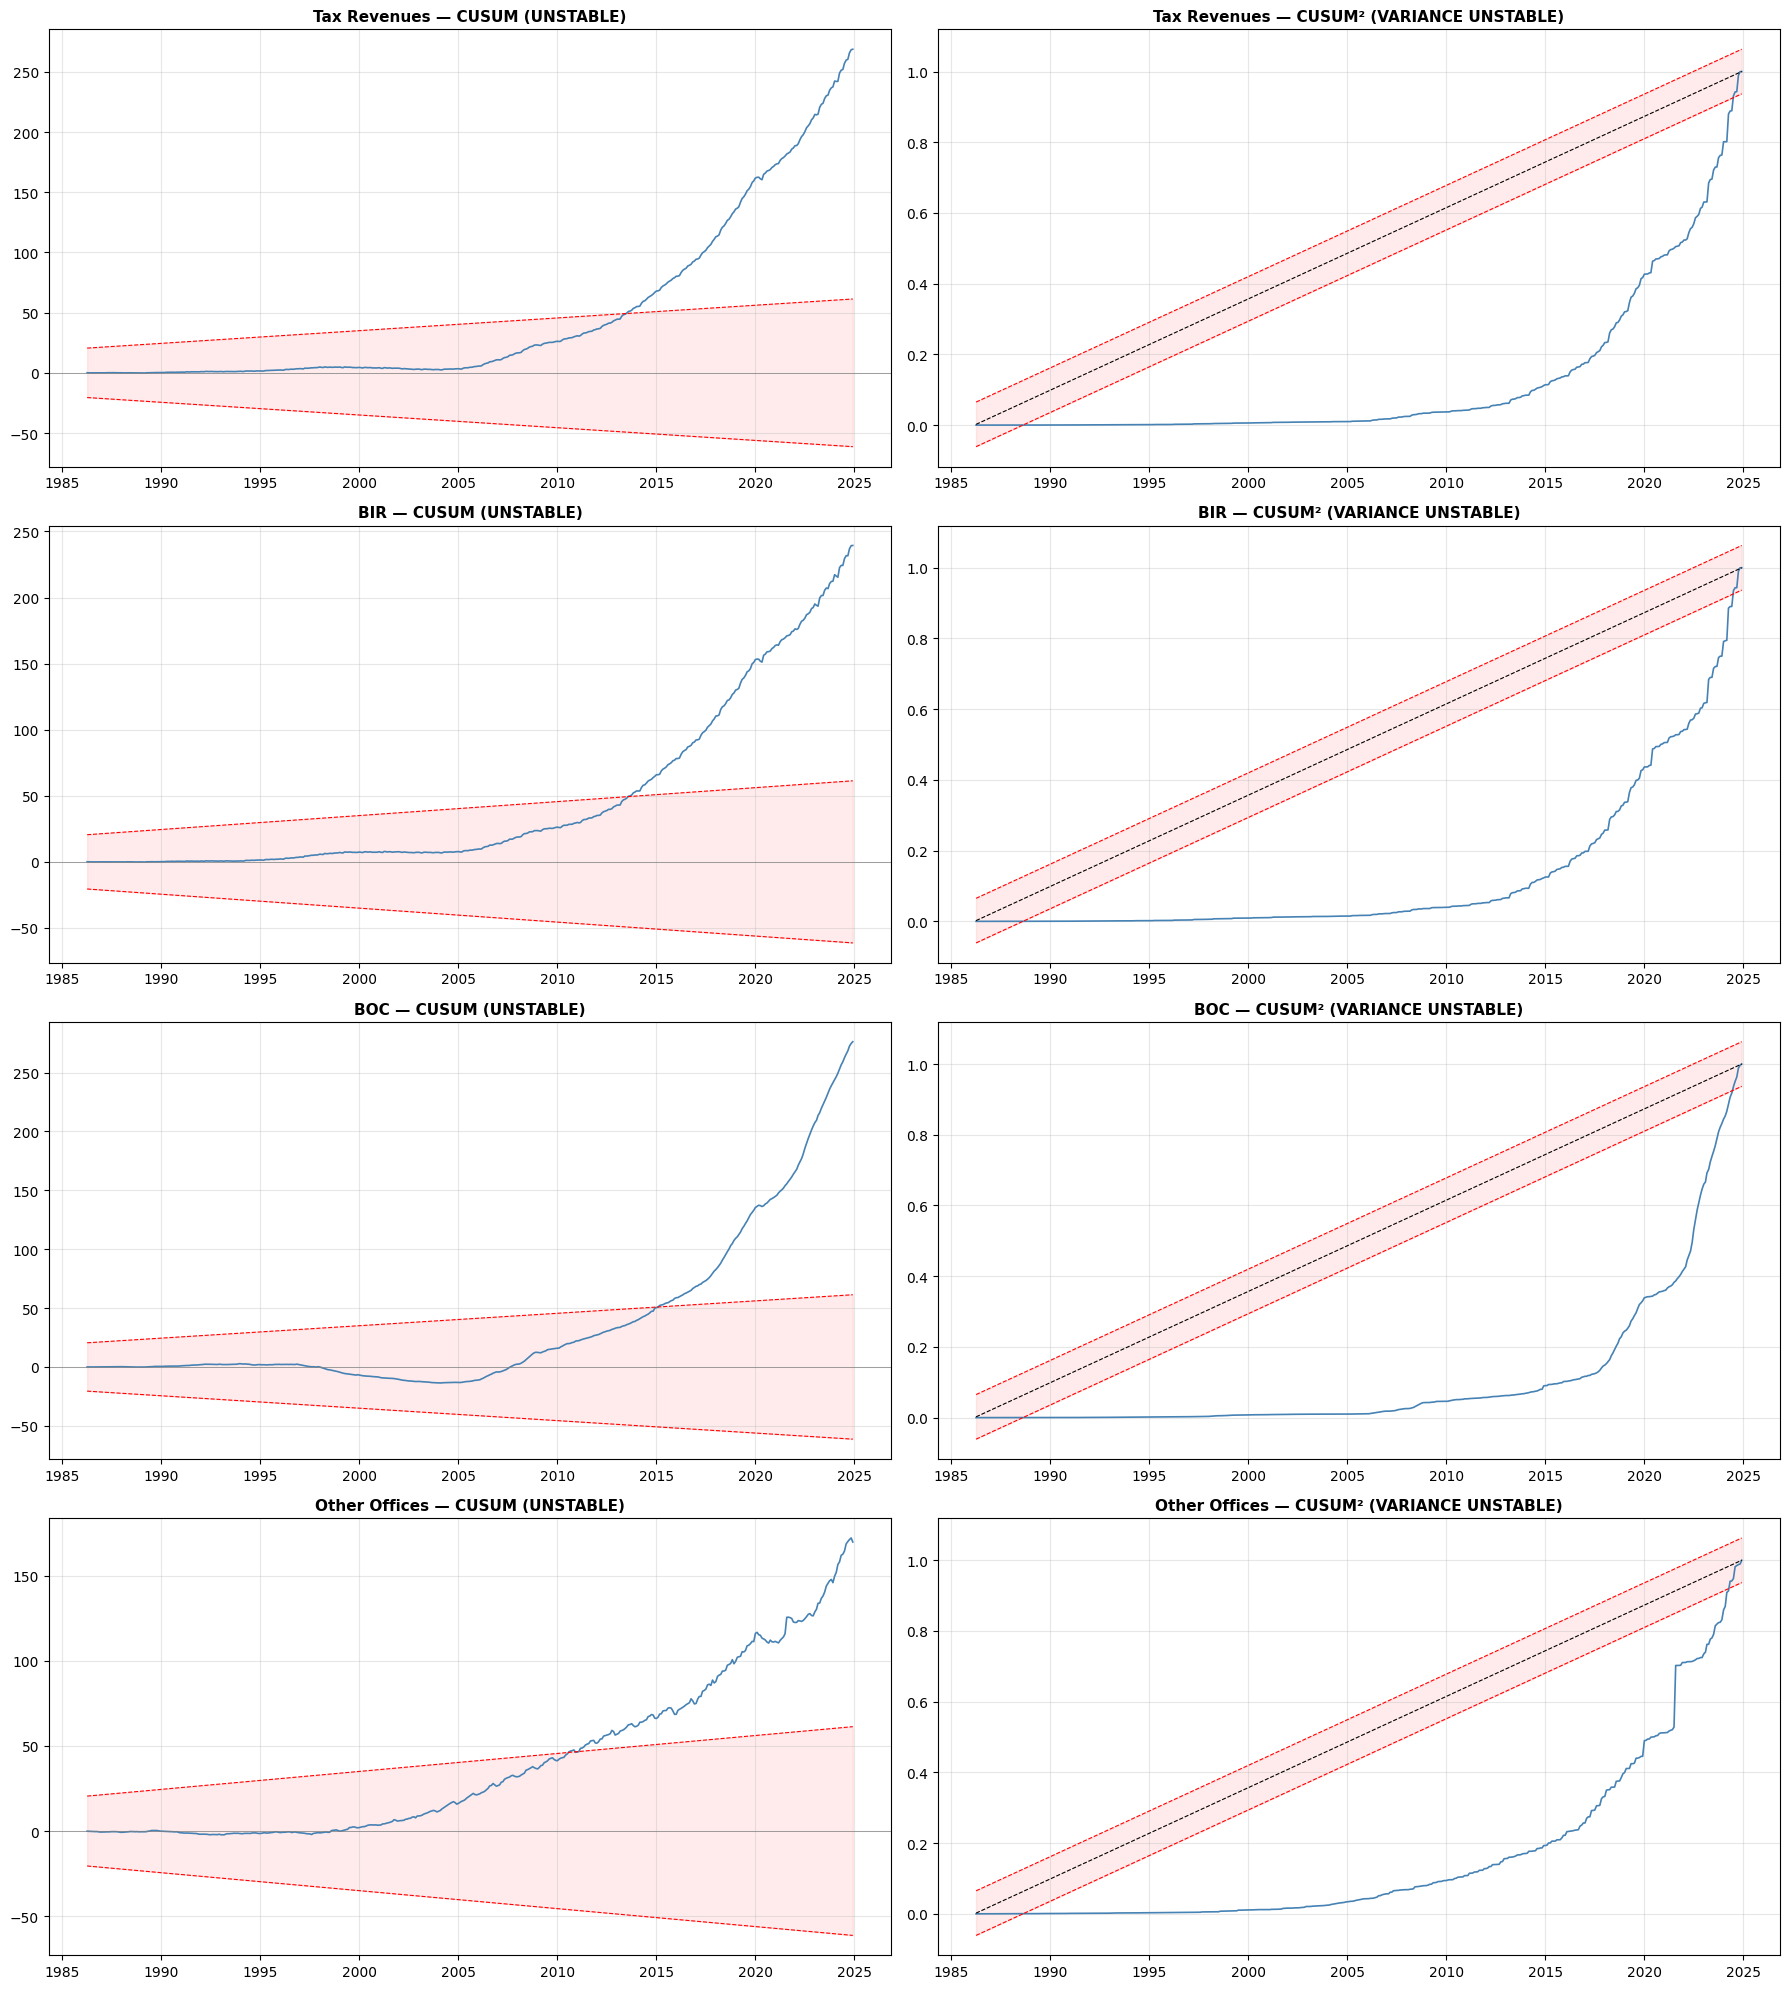


  CUSUM SUMMARY
  Tax Revenues          CUSUM: Unstable         CUSUM²: Unstable
  BIR                   CUSUM: Unstable         CUSUM²: Unstable
  BOC                   CUSUM: Unstable         CUSUM²: Unstable
  Other Offices         CUSUM: Unstable         CUSUM²: Unstable


In [12]:
def cusum_test(y):
    """CUSUM test based on recursive OLS residuals."""
    y = np.array(y, dtype=float).flatten()
    T = len(y)
    X = np.column_stack([np.ones(T), np.arange(T)])
    k = X.shape[1]
    start = k + 1

    recursive_residuals = []
    for t in range(start, T):
        X_t, y_t = X[:t], y[:t]
        beta = np.linalg.lstsq(X_t, y_t, rcond=None)[0]
        y_hat = X[t] @ beta
        e_t = y[t] - y_hat
        H = X[t] @ np.linalg.pinv(X_t.T @ X_t) @ X[t]
        f_t = np.sqrt(1 + H)
        recursive_residuals.append(e_t / (f_t + 1e-10))

    w = np.array(recursive_residuals)
    sigma_hat = np.std(w) + 1e-10
    n = len(w)
    cusum = np.cumsum(w) / sigma_hat
    a = 0.948
    t_vals = np.arange(1, n + 1)
    upper = a * np.sqrt(n) + 2 * a * t_vals / np.sqrt(n)
    lower = -upper
    significant = bool(np.any(np.abs(cusum) > upper))
    return {'cusum': cusum, 'upper': upper, 'lower': lower,
            'significant': significant, 'start_index': start}


def cusum_sq_test(y):
    """CUSUM-of-Squares — detects variance instability."""
    y = np.array(y, dtype=float).flatten()
    T = len(y)
    X = np.column_stack([np.ones(T), np.arange(T)])
    k = X.shape[1]
    start = k + 1

    w2 = []
    for t in range(start, T):
        X_t, y_t = X[:t], y[:t]
        beta = np.linalg.lstsq(X_t, y_t, rcond=None)[0]
        e_t = y[t] - X[t] @ beta
        w2.append(e_t ** 2)

    w2 = np.array(w2)
    total = np.sum(w2) + 1e-10
    cusum_sq = np.cumsum(w2) / total
    n = len(w2)
    expected = np.arange(1, n + 1) / n
    c_alpha = 1.36 / np.sqrt(n)
    upper = expected + c_alpha
    lower = expected - c_alpha
    significant = bool(np.any((cusum_sq > upper) | (cusum_sq < lower)))
    return {'cusum_sq': cusum_sq, 'expected': expected,
            'upper': upper, 'lower': lower,
            'significant': significant, 'start_index': start}

# Run and plot
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
for i, label in enumerate(BREAK_LABELS):
    y = raw_series[label]['values']
    dates = raw_series[label]['dates']

    cr = cusum_test(y)
    ax = axes[i, 0]
    n = len(cr['cusum'])
    x = dates[cr['start_index']:cr['start_index'] + n]
    ax.plot(x, cr['cusum'], color='steelblue', linewidth=1.2)
    ax.plot(x, cr['upper'], 'r--', linewidth=0.8)
    ax.plot(x, cr['lower'], 'r--', linewidth=0.8)
    ax.fill_between(x, cr['lower'], cr['upper'], alpha=0.08, color='red')
    ax.axhline(0, color='gray', linewidth=0.5)
    sig = "UNSTABLE" if cr['significant'] else "STABLE"
    ax.set_title(f'{label} — CUSUM ({sig})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    csr = cusum_sq_test(y)
    ax2 = axes[i, 1]
    n2 = len(csr['cusum_sq'])
    x2 = dates[csr['start_index']:csr['start_index'] + n2]
    ax2.plot(x2, csr['cusum_sq'], color='steelblue', linewidth=1.2)
    ax2.plot(x2, csr['expected'], 'k--', linewidth=0.8, label='Expected')
    ax2.plot(x2, csr['upper'], 'r--', linewidth=0.8)
    ax2.plot(x2, csr['lower'], 'r--', linewidth=0.8)
    ax2.fill_between(x2, csr['lower'], csr['upper'], alpha=0.08, color='red')
    sig2 = "VARIANCE UNSTABLE" if csr['significant'] else "VARIANCE STABLE"
    ax2.set_title(f'{label} — CUSUM² ({sig2})', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"  CUSUM SUMMARY")
print(f"{'='*50}")
for label in BREAK_LABELS:
    y = raw_series[label]['values']
    cr = cusum_test(y)
    csr = cusum_sq_test(y)
    print(f"  {label:20s}  CUSUM: {'Unstable' if cr['significant'] else 'Stable':15s}  "
          f"CUSUM²: {'Unstable' if csr['significant'] else 'Stable'}")

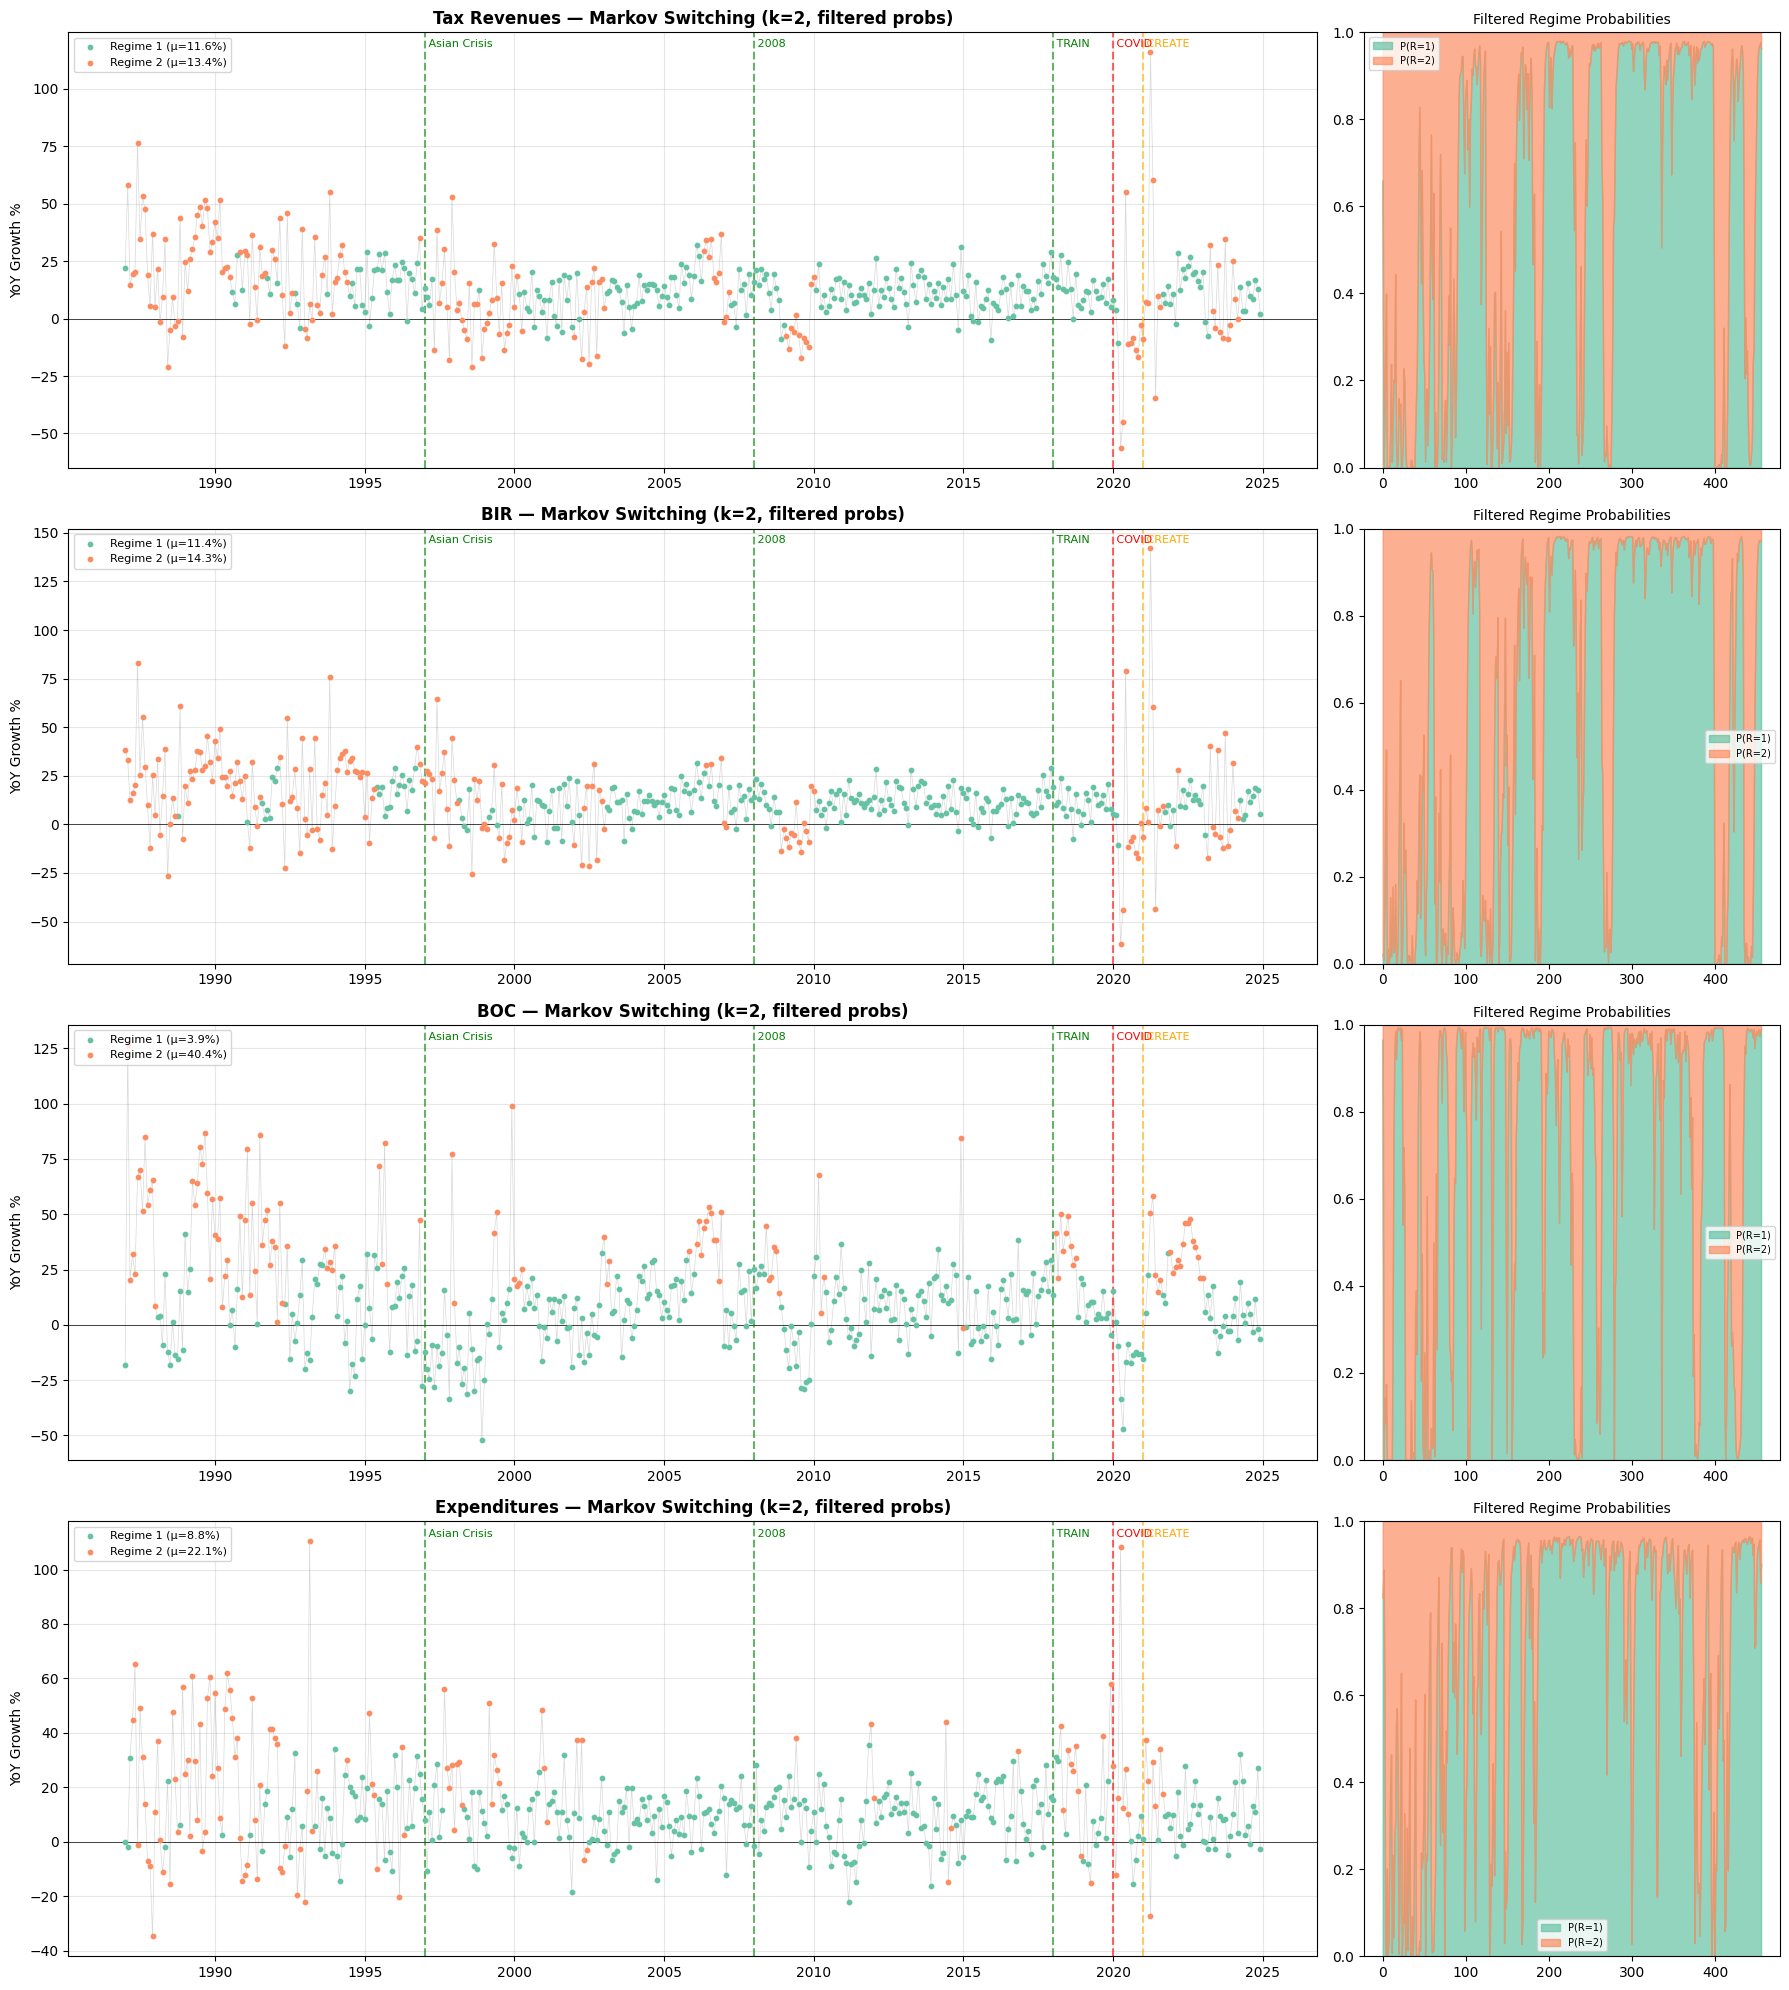


  Tax Revenues (k=2):
    Regime 1: mean=11.6%, std=8.1%, fraction=61.4%
    Regime 2: mean=13.4%, std=22.6%, fraction=38.6%
    Transition matrix (rows: from, cols: to):
          Regime 1  Regime 2
Regime 1  0.966689  0.047387
Regime 2  0.033311  0.952613

  BIR (k=2):
    Regime 1: mean=11.4%, std=7.9%, fraction=58.6%
    Regime 2: mean=14.3%, std=24.2%, fraction=41.4%
    Transition matrix (rows: from, cols: to):
          Regime 1  Regime 2
Regime 1  0.966669  0.045466
Regime 2  0.033331  0.954534

  BOC (k=2):
    Regime 1: mean=3.9%, std=15.5%, fraction=74.1%
    Regime 2: mean=40.4%, std=22.0%, fraction=25.9%
    Transition matrix (rows: from, cols: to):
          Regime 1  Regime 2
Regime 1  0.946171  0.134213
Regime 2  0.053829  0.865787

  Expenditures (k=2):
    Regime 1: mean=8.8%, std=10.5%, fraction=73.5%
    Regime 2: mean=22.1%, std=25.4%, fraction=26.5%
    Transition matrix (rows: from, cols: to):
          Regime 1  Regime 2
Regime 1  0.949137  0.108587
Regime 2  0

In [ ]:
for label in BREAK_LABELS:
    y = raw_series[label]['values']               # original level series
    dates = raw_series[label]['dates']

    # Year‑over‑year percentage growth
    # (value_t / value_{t-12} - 1) * 100
    # This uses only information up to time t (past values)
    growth = (y[12:] - y[:-12]) / (np.abs(y[:-12]) + 1e-8) * 100
    growth_dates = dates[12:]                      # dates corresponding to growth values

    # Store in raw_series (overwrites any previous 'growth' key)
    raw_series[label]['growth'] = growth
    raw_series[label]['growth_dates'] = growth_dates

# ----------------------------------------------------------------------
# 2. Fit Markov switching models (still k=3 for all series)
# ----------------------------------------------------------------------
ms_results = {}

for label in BREAK_LABELS:
    y_growth = raw_series[label]['growth']
    k = 2

    mod = MarkovRegression(y_growth, k_regimes=k, trend='c',
                           switching_variance=True)
    res = mod.fit(maxiter=500, disp=False)

    # Filtered probabilities – use only past information (no lookahead)
    probs = res.filtered_marginal_probabilities

    ms_results[label] = {
        'model': res,
        'k': k,
        'filtered_probs': probs,                 # store filtered (real‑time)
        'filtered_labels': probs.argmax(axis=1), # hard labels from filtered probs
    }

# ----------------------------------------------------------------------
# 3. Plotting 
# ----------------------------------------------------------------------
regime_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']
fig, axes = plt.subplots(4, 2, figsize=(18, 20),
                         gridspec_kw={'width_ratios': [3, 1]})

for i, label in enumerate(BREAK_LABELS):
    y_growth = raw_series[label]['growth']
    dates = raw_series[label]['growth_dates']
    ms = ms_results[label]
    k = ms['k']
    probs = ms['filtered_probs']                 # using filtered for plot
    labels_arr = ms['filtered_labels']

    ax = axes[i, 0]
    for j in range(k):
        mask = labels_arr == j
        if mask.any():
            mu = y_growth[mask].mean()
            ax.scatter(dates[mask], y_growth[mask],
                       c=regime_colors[j % len(regime_colors)], s=10,
                       label=f"Regime {j+1} (μ={mu:.1f}%)", zorder=3)
    ax.plot(dates, y_growth, color='gray', linewidth=0.5, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)

    # Vertical lines for known events (for reference only)
    for year, name, color in [(1997, 'Asian Crisis', 'green'),
                               (2008, '2008', 'green'),
                               (2018, 'TRAIN', 'green'),
                               (2020, 'COVID', 'red'),
                               (2021, 'CREATE', 'orange')]:
        ts = pd.Timestamp(f'{year}-01-01')
        if dates[0] <= ts <= dates[-1]:
            ax.axvline(ts, color=color, linestyle='--', linewidth=1.5, alpha=0.6)
            ax.text(ts, ax.get_ylim()[1] * 0.95, f' {name}', fontsize=8, color=color)

    ax.set_title(f'{label} — Markov Switching (k={k}, filtered probs)',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('YoY Growth %')

    ax2 = axes[i, 1]
    bottom = np.zeros(len(y_growth))
    for j in range(k):
        ax2.fill_between(range(len(y_growth)), bottom, bottom + probs[:, j],
                         alpha=0.7, color=regime_colors[j % len(regime_colors)],
                         label=f'P(R={j+1})')
        bottom += probs[:, j]
    ax2.set_ylim(0, 1)
    ax2.set_title('Filtered Regime Probabilities', fontsize=10)
    ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 4. Print summary statistics 
# ----------------------------------------------------------------------
for label in BREAK_LABELS:
    ms = ms_results[label]
    res = ms['model']
    k = ms['k']
    y_growth = raw_series[label]['growth']
    labels_arr = ms['filtered_labels']

    print(f"\n  {label} (k={k}):")
    for j in range(k):
        mask = labels_arr == j
        if mask.any():
            print(f"    Regime {j+1}: mean={y_growth[mask].mean():.1f}%, "
                  f"std={y_growth[mask].std():.1f}%, fraction={np.mean(mask):.1%}")

    # Transition matrix (already estimated without lookahead)
    P = np.squeeze(res.regime_transition)   # shape (k, k)
    print(f"    Transition matrix (rows: from, cols: to):")
    print(pd.DataFrame(P,
                   index=[f'Regime {i+1}' for i in range(k)],
                   columns=[f'Regime {j+1}' for j in range(k)]))

In [9]:
features = df[['BIR', 'BOC',  'TotalTrade_PHPMN',
               'NominalGDP_disagg', 'Inflation', 'USDPHP']].copy()

pct_cols = [ 'BIR', 'BOC',
            'TotalTrade_PHPMN', 'NominalGDP_disagg', 'USDPHP']
features_pct = features[pct_cols].pct_change(12)*100

inflation_diff = features[['Inflation']].diff(12)

features_growth = pd.concat([features_pct, inflation_diff], axis=1).dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features_growth)

bics = []
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                           n_init=10, random_state=42)
    gmm.fit(X)
    bics.append((k, gmm.bic(X)))
    print(f"  k={k}: BIC={gmm.bic(X):.0f}")

best_k = min(bics, key=lambda x: x[1])[0]

gmm = GaussianMixture(n_components=3, covariance_type='full',
                      init_params='random', n_init=10, random_state=42)
gmm.fit(X)
labels = gmm.predict(X)
probs = gmm.predict_proba(X)

  k=2: BIC=5915
  k=3: BIC=5909
  k=4: BIC=5935
  k=5: BIC=5955
  k=6: BIC=5940


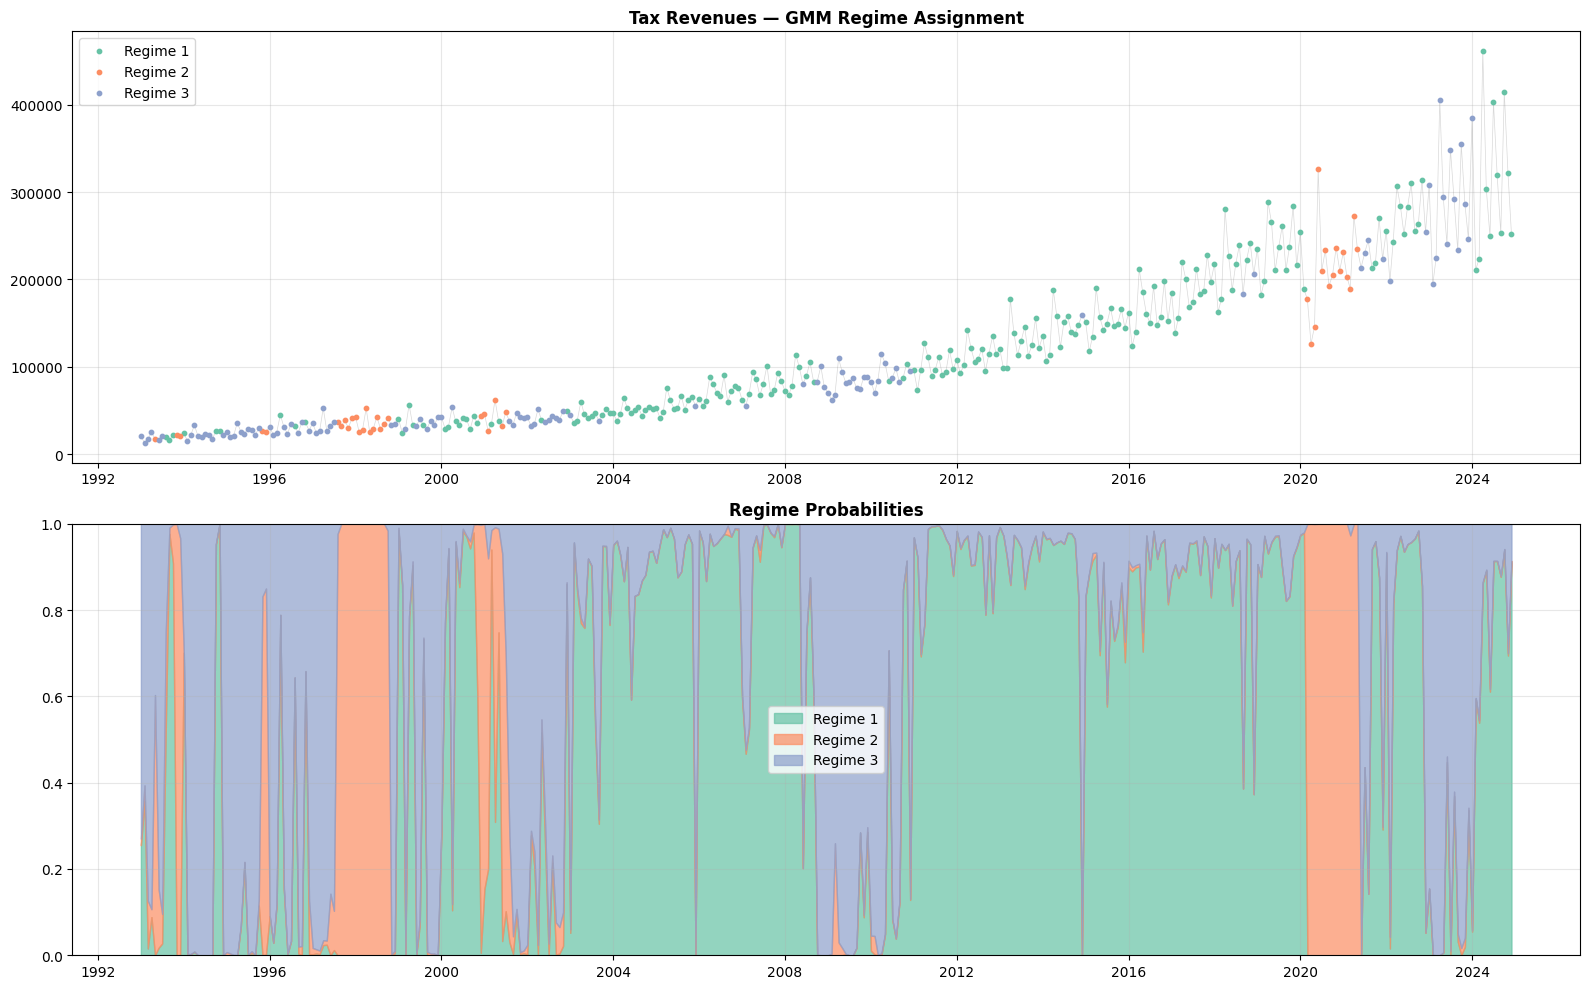


  GMM REGIME CHARACTERISTICS

  Regime 1 (225 months, 58.6%):
    BIR                      : mean=   12.4%, std=   7.7%
    BOC                      : mean=   14.4%, std=  15.3%
    TotalTrade_PHPMN         : mean=    9.2%, std=  12.0%
    NominalGDP_disagg        : mean=    9.5%, std=   2.4%
    USDPHP                   : mean=    1.2%, std=   7.0%
    Inflation                : mean=    0.1%, std=   2.5%

  Regime 2 (41 months, 10.7%):
    BIR                      : mean=   11.5%, std=  34.5%
    BOC                      : mean=   -2.8%, std=  25.0%
    TotalTrade_PHPMN         : mean=   22.4%, std=  33.4%
    NominalGDP_disagg        : mean=    3.6%, std=   9.4%
    USDPHP                   : mean=   17.4%, std=  21.6%
    Inflation                : mean=    0.9%, std=   2.3%

  Regime 3 (118 months, 30.7%):
    BIR                      : mean=    8.6%, std=  17.3%
    BOC                      : mean=    6.4%, std=  24.3%
    TotalTrade_PHPMN         : mean=   10.3%, std=  17.1%
  

In [10]:
regime_dates = features_growth.index

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
regime_colors = ['#66c2a5', '#fc8d62', '#8da0cb']
regime_names = [f'Regime {i+1}' for i in range(3)]

# Top: Tax Revenues colored by regime
ax = axes[0]
y = df.loc[regime_dates, 'Tax Revenues']
for j in range(3):
    mask = labels == j
    ax.scatter(regime_dates[mask], y.values[mask], c=regime_colors[j],
               s=10, label=regime_names[j], zorder=3)
ax.plot(regime_dates, y.values, color='gray', linewidth=0.5, alpha=0.3)
ax.set_title('Tax Revenues — GMM Regime Assignment', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom: Regime probabilities
ax2 = axes[1]
bottom = np.zeros(len(regime_dates))
for j in range(3):
    ax2.fill_between(regime_dates, bottom, bottom + probs[:, j],
                     alpha=0.7, color=regime_colors[j], label=regime_names[j])
    bottom += probs[:, j]
ax2.set_ylim(0, 1)
ax2.set_title('Regime Probabilities', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print regime characteristics
print(f"\n{'='*60}")
print(f"  GMM REGIME CHARACTERISTICS")
print(f"{'='*60}")
for j in range(3):
    mask = labels == j
    print(f"\n  Regime {j+1} ({mask.sum()} months, {mask.mean():.1%}):")
    for col in features_growth.columns:
        vals = features_growth.loc[mask, col]
        print(f"    {col:25s}: mean={vals.mean():7.1f}%, std={vals.std():6.1f}%")